In [24]:
# PHYS 311
# LAB 4 - TWO-BODY COLLISION
# Alexander Berry
# September 14, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt

## Part A - 1D Collisions with Restitution

In this part, we model one-dimensional collisions using the coefficient of restitution. We initially test 3 limiting cases for elastic collisions, then we compare the momentum and kinetic energy for collisions with varying coefficients of restitution.

In [25]:
# PART A - 1D COLLISIONS WITH RESTITUTION

# A1. COLLISION FUNCTION

def collide_1d(m1, m2, u1, u2, e=1.0):
    """1D collision with restitution e. e=1 elastic, e=0 perfectly inelastic."""
    
    total_m = m1 + m2
    
    # Center-of-mass velocity is unchanged by the collision
    v_cm = (m1 * u1 + m2 * u2) / total_m
    
    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)
    
    return v1, v2


def p_total(m1, m2, v1, v2):
    """Return total momentum."""
    
    return m1 * v1 + m2 * v2


def ke_total(m1, m2, v1, v2):
    """Return total kinetic energy."""
    
    return 0.5 * m1 * v1**2 + 0.5 * m2 * v2**2


# A2. LIMITING CASE 1 - EQUAL MASSES

m1, m2 = 1.0, 1.0
u1, u2 = 3.0, 0.0

v1, v2 = collide_1d(m1, m2, u1, u2, e=1.0)

print("CASE 1 - EQUAL MASSES")
print(f"Initial velocities: u1 = {u1:.4f} m/s, u2 = {u2:.4f} m/s")
print(f"Final velocities:   v1 = {v1:.4f} m/s, v2 = {v2:.4f} m/s")


# A3. LIMITING CASE 2 - LIGHT BALL INTO HEAVY BALL

m1, m2 = 0.1, 100.0
u1, u2 = 4.0, 0.0

v1, v2 = collide_1d(m1, m2, u1, u2, e=1.0)

print("\nCASE 2 - LIGHT BALL INTO HEAVY BALL")
print(f"Initial velocities: u1 = {u1:.4f} m/s, u2 = {u2:.4f} m/s")
print(f"Final velocities:   v1 = {v1:.4f} m/s, v2 = {v2:.4f} m/s")


# A4. LIMITING CASE 3 - HEAVY BALL INTO LIGHT BALL

m1, m2 = 100.0, 0.1
u1, u2 = 4.0, 0.0

v1, v2 = collide_1d(m1, m2, u1, u2, e=1.0)

print("\nCASE 3 - HEAVY BALL INTO LIGHT BALL")
print(f"Initial velocities: u1 = {u1:.4f} m/s, u2 = {u2:.4f} m/s")
print(f"Final velocities:   v1 = {v1:.4f} m/s, v2 = {v2:.4f} m/s")


# A5. MOMENTUM AND ENERGY CONSERVATION

m1, m2 = 2.0, 3.0
u1, u2 = 4.0, 0.0

p_before = p_total(m1, m2, u1, u2)
ke_before = ke_total(m1, m2, u1, u2)

e_values = [1.0, 0.5, 0.0]

print("\nCONSERVATION TABLE")

print(
    f"{'e':>4} | "
    f"{'v1 (m/s)':>10} | "
    f"{'v2 (m/s)':>10} | "
    f"{'p before':>10} | "
    f"{'p after':>10} | "
    f"{'KE before':>10} | "
    f"{'KE after':>10}"
)

print("-" * 86)

for e in e_values:
    
    v1, v2 = collide_1d(m1, m2, u1, u2, e)
    
    p_after = p_total(m1, m2, v1, v2)
    ke_after = ke_total(m1, m2, v1, v2)
    
    print(
        f"{e:4.1f} | "
        f"{v1:10.4f} | "
        f"{v2:10.4f} | "
        f"{p_before:10.4f} | "
        f"{p_after:10.4f} | "
        f"{ke_before:10.4f} | "
        f"{ke_after:10.4f}"
    )

CASE 1 - EQUAL MASSES
Initial velocities: u1 = 3.0000 m/s, u2 = 0.0000 m/s
Final velocities:   v1 = 0.0000 m/s, v2 = 3.0000 m/s

CASE 2 - LIGHT BALL INTO HEAVY BALL
Initial velocities: u1 = 4.0000 m/s, u2 = 0.0000 m/s
Final velocities:   v1 = -3.9920 m/s, v2 = 0.0080 m/s

CASE 3 - HEAVY BALL INTO LIGHT BALL
Initial velocities: u1 = 4.0000 m/s, u2 = 0.0000 m/s
Final velocities:   v1 = 3.9920 m/s, v2 = 7.9920 m/s

CONSERVATION TABLE
   e |   v1 (m/s) |   v2 (m/s) |   p before |    p after |  KE before |   KE after
--------------------------------------------------------------------------------------
 1.0 |    -0.8000 |     3.2000 |     8.0000 |     8.0000 |    16.0000 |    16.0000
 0.5 |     0.4000 |     2.4000 |     8.0000 |     8.0000 |    16.0000 |     8.8000
 0.0 |     1.6000 |     1.6000 |     8.0000 |     8.0000 |    16.0000 |     6.4000


## Part A - Intrepretation

The 3 limiting cases behaved as expected. When the masses are equal, the objects simply exchanged velocities.  The initially moving 1.0 kg mass came to rest where as the stationary mass moved at 3.0000 m/s. 

When the 0.1 kg collided with the 100.0 kg stationary object however, the light object nearly reversed direction with a final velocity of -3.9920 m/s. The heavy object on the other hand only moved at 0.0080 m/s.

When the opposite was true, and the 100.0 kg object barely slowed, finishing at 3.9920 m/s, whereas the 0.1 kg object accelerated to 7.9920 m/s.

Furthermore, the conservation results matched the expected behavior. The Total momentum remained constant at 8.0000 kg m/s for all three coefficients of restitution. 

For the elastic collision (e=1.0), the kinetic energy was fully conserved at 16.0000 J. For the (e=0.5) collision, the final kinetic energy decreased to 8.8000 J, whereas the perfectly inelastic collision (e=0.0), decreased further to 6.4 J. 

This behavior demonstrates that momentum is conserved regardless of the coefficient of restitution. The kinetic energy however decreases as the collision becomes more inelastic. In the real world, released heat, sound, or deformation can be to blame for the missing kinetic energy.

## Part B - 2D Collisions in a Box

In this part, we extended the collision model into two dimensions. Two circular bodies move inside a rectangular box and undergo elastic collisions with both one another and the walls. 

Number of ball-ball collisions: 2
Initial KE = 5.79375000 J
Final KE   = 5.79375000 J
Maximum KE deviation = 2.665e-15 J


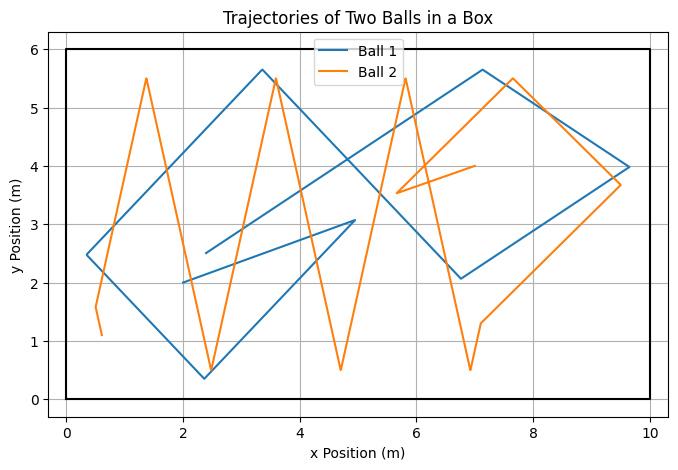

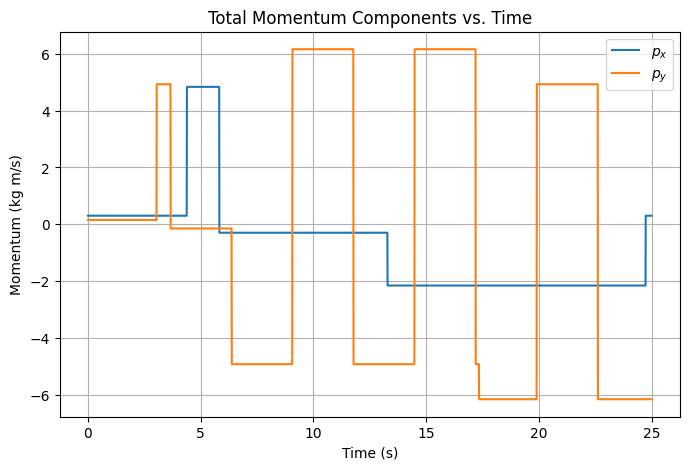

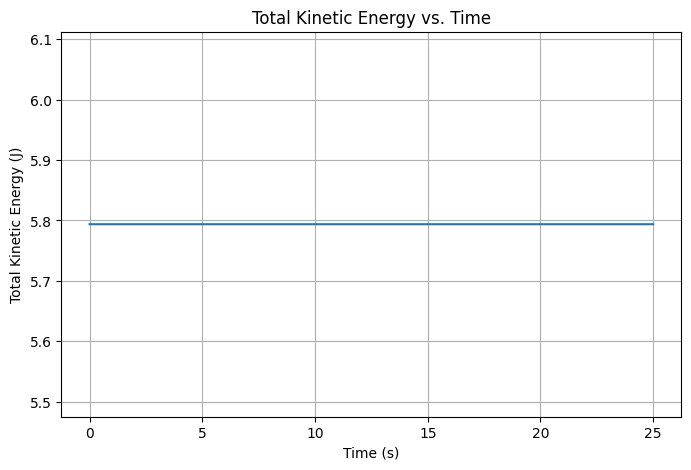

In [26]:
# PART B - 2D COLLISIONS IN A BOX

# B1. 2D COLLISION FUNCTION

def collide_2d(m1, m2, r1, r2, v1, v2, e=1.0):
    """Resolve a 2D collision between two circular bodies."""
    
    r1 = np.asarray(r1, dtype=float)
    r2 = np.asarray(r2, dtype=float)
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)
    
    # Vector from body 1 to body 2
    n = r2 - r1
    
    # Distance between centers
    dist = np.linalg.norm(n)
    
    if dist == 0:
        return v1, v2
    
    # Unit normal vector
    n = n / dist
    
    # Normal velocity components
    u1n = np.dot(v1, n)
    u2n = np.dot(v2, n)
    
    # Tangential velocity components
    v1t = v1 - u1n * n
    v2t = v2 - u2n * n
    
    # Apply the 1D collision equation to normal components
    new1n, new2n = collide_1d(
        m1,
        m2,
        u1n,
        u2n,
        e
    )
    
    # Recombine normal and tangential components
    new_v1 = v1t + new1n * n
    new_v2 = v2t + new2n * n
    
    return new_v1, new_v2


# B2. COLLISION DETECTION

def overlapping(r1, r2, radius1, radius2):
    """Return True if two circular bodies overlap."""
    
    distance = np.linalg.norm(
        np.asarray(r2) - np.asarray(r1)
    )
    
    return distance < (radius1 + radius2)


# B3. TOTAL MOMENTUM AND KINETIC ENERGY

def total_momentum(bodies):
    """Return total 2D momentum."""
    
    return sum(
        (body["m"] * body["v"] for body in bodies),
        start=np.zeros(2)
    )


def total_ke(bodies):
    """Return total kinetic energy."""
    
    return sum(
        0.5
        * body["m"]
        * np.dot(body["v"], body["v"])
        for body in bodies
    )


# B4. WALL COLLISIONS

def bounce_walls(body, W, H):
    """Reflect a body's velocity when it hits a wall."""
    
    R = body["radius"]
    
    x, y = body["r"]
    vx, vy = body["v"]
    
    # Left wall
    if x - R < 0:
        x = R
        
        if vx < 0:
            vx = -vx
    
    # Right wall
    elif x + R > W:
        x = W - R
        
        if vx > 0:
            vx = -vx
    
    # Bottom wall
    if y - R < 0:
        y = R
        
        if vy < 0:
            vy = -vy
    
    # Top wall
    elif y + R > H:
        y = H - R
        
        if vy > 0:
            vy = -vy
    
    body["r"] = np.array([x, y], dtype=float)
    body["v"] = np.array([vx, vy], dtype=float)


# B5. COPY BODY LIST

def copy_bodies(bodies):
    """Return a fresh copy of a list of bodies."""
    
    return [
        {
            "m": body["m"],
            "r": np.array(body["r"], dtype=float).copy(),
            "v": np.array(body["v"], dtype=float).copy(),
            "radius": body["radius"]
        }
        for body in bodies
    ]


# B6. SIMULATION FUNCTION

def simulate_box(initial_bodies, W, H, dt, n_steps, e=1.0):
    """Simulate two circular bodies moving and colliding inside a box."""
    
    bodies = copy_bodies(initial_bodies)
    
    n_bodies = len(bodies)
    
    time = np.arange(n_steps + 1) * dt
    
    positions = np.zeros(
        (n_steps + 1, n_bodies, 2)
    )
    
    momentum = np.zeros(
        (n_steps + 1, 2)
    )
    
    kinetic_energy = np.zeros(
        n_steps + 1
    )
    
    # Initial values
    positions[0] = [
        body["r"] for body in bodies
    ]
    
    momentum[0] = total_momentum(bodies)
    kinetic_energy[0] = total_ke(bodies)
    
    collision_count = 0
    
    for step in range(1, n_steps + 1):
        
        # Euler-Cromer update
        for body in bodies:
            
            acceleration = np.zeros(2)
            
            body["v"] = (
                body["v"]
                + acceleration * dt
            )
            
            body["r"] = (
                body["r"]
                + body["v"] * dt
            )
            
            bounce_walls(body, W, H)
        
        body1 = bodies[0]
        body2 = bodies[1]
        
        # Only resolve collision if bodies are approaching
        approaching = np.dot(
            body2["v"] - body1["v"],
            body2["r"] - body1["r"]
        ) < 0
        
        if (
            overlapping(
                body1["r"],
                body2["r"],
                body1["radius"],
                body2["radius"]
            )
            and approaching
        ):
            
            body1["v"], body2["v"] = collide_2d(
                body1["m"],
                body2["m"],
                body1["r"],
                body2["r"],
                body1["v"],
                body2["v"],
                e
            )
            
            collision_count += 1
        
        # Save results
        positions[step] = [
            body["r"] for body in bodies
        ]
        
        momentum[step] = total_momentum(bodies)
        kinetic_energy[step] = total_ke(bodies)
    
    return (
        time,
        positions,
        momentum,
        kinetic_energy,
        collision_count
    )


# B7. INITIAL CONDITIONS

W = 10.0
H = 6.0

dt = 0.01
n_steps = 2500

e = 1.0

bodies_B = [
    {
        "m": 1.5,
        "r": np.array([2.0, 2.0]),
        "v": np.array([2.2, 0.8]),
        "radius": 0.35
    },
    {
        "m": 3.0,
        "r": np.array([7.0, 4.0]),
        "v": np.array([-1.0, -0.35]),
        "radius": 0.50
    }
]


# B8. RUN SIMULATION

time_B, positions_B, momentum_B, ke_B, collisions_B = simulate_box(
    bodies_B,
    W,
    H,
    dt,
    n_steps,
    e
)

print(f"Number of ball-ball collisions: {collisions_B}")
print(f"Initial KE = {ke_B[0]:.8f} J")
print(f"Final KE   = {ke_B[-1]:.8f} J")
print(
    f"Maximum KE deviation = "
    f"{np.max(np.abs(ke_B - ke_B[0])):.3e} J"
)


# B9. TRAJECTORY PLOT

plt.figure(figsize=(8, 5))

plt.plot(
    positions_B[:, 0, 0],
    positions_B[:, 0, 1],
    label="Ball 1"
)

plt.plot(
    positions_B[:, 1, 0],
    positions_B[:, 1, 1],
    label="Ball 2"
)

# Draw box boundaries
plt.plot(
    [0, W, W, 0, 0],
    [0, 0, H, H, 0],
    "k-"
)

plt.xlabel("x Position (m)")
plt.ylabel("y Position (m)")
plt.title("Trajectories of Two Balls in a Box")

plt.xlim(0, W)
plt.ylim(0, H)

plt.axis("equal")
plt.grid()
plt.legend()

plt.show()


# B10. MOMENTUM COMPONENTS

plt.figure(figsize=(8, 5))

plt.plot(
    time_B,
    momentum_B[:, 0],
    label=r"$p_x$"
)

plt.plot(
    time_B,
    momentum_B[:, 1],
    label=r"$p_y$"
)

plt.xlabel("Time (s)")
plt.ylabel("Momentum (kg m/s)")
plt.title("Total Momentum Components vs. Time")

plt.grid()
plt.legend()

plt.show()


# B11. TOTAL KINETIC ENERGY

plt.figure(figsize=(8, 5))

plt.plot(
    time_B,
    ke_B
)

plt.xlabel("Time (s)")
plt.ylabel("Total Kinetic Energy (J)")
plt.title("Total Kinetic Energy vs. Time")

plt.grid()

plt.show()

## Part B - Interpretation

The two-ball simulation prodcuced two ball to ball collisions during the 25 s run. The above trajectory plot demonstrates both balls moving throughout the box and reflecting from the boundaries as expected.

The total momentum components changed whenever a ball collided with a wall. This was expected however because the walls extert external impulses on the two-ball system, which ultimately impacts the system's momentum. 

Between the wall collisions, the momentum components remain constant, while the ball to ball collisions conserve the total momentum of the two balls themselves.

Finally, the total kinetic energy remained practically constant throughout the simulation. The initial and final kinetic energies were both 5.79375000 J, with a maximum deviation of only 2.665e-15 J. This incredibly small gap is consistent with what we know of floating-point numerical precision, and thereby confirms that the elastic ball to ball and wall collisions are actively conserving kinetic energy as expected.

## Part C - Inelastic Collisions and Energy Accounting

In this part, we investigate two-dimensional collisions across various coefficients of resitution. Using the same initial conditions across each test, we are able to compare the total kinetic energy over time and calclate the kinetic energy lost during the first collision. 

Furthermore, we remove the walls and follow the center of mass of the two-body system. Given no external forces, the center of mass is expected to move in a straight line at a velocity.

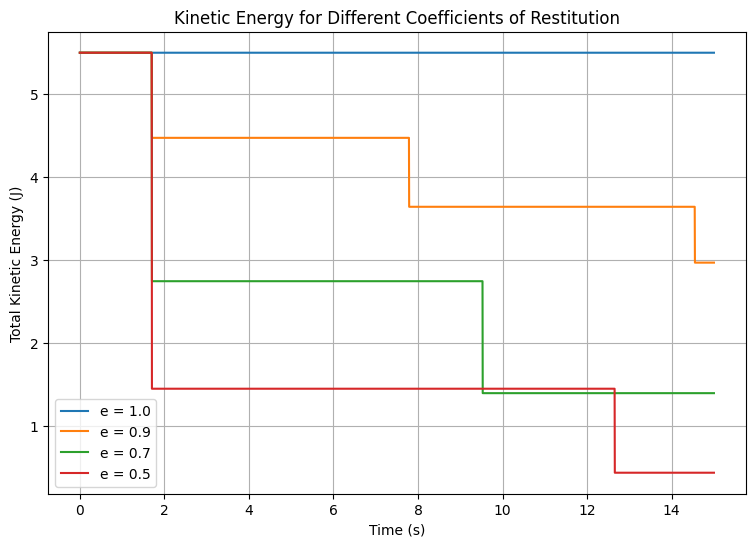

FIRST COLLISION ENERGY LOSS
    e |  Numerical Loss |     Theory Loss |  Numerical % |   Theory %
----------------------------------------------------------------------
  1.0 |        0.000000 |        0.000000 |      0.0000% |    0.0000%
  0.9 |        1.026000 |        1.026000 |     18.6545% |   18.6545%
  0.7 |        2.754000 |        2.754000 |     50.0727% |   50.0727%
  0.5 |        4.050000 |        4.050000 |     73.6364% |   73.6364%


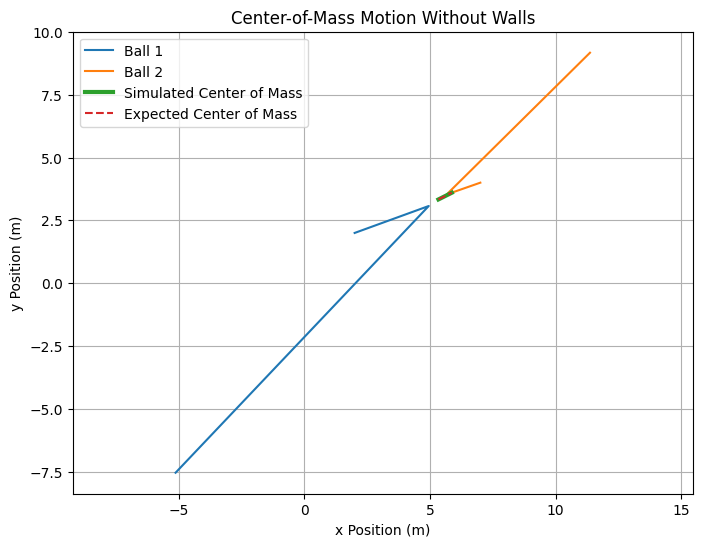


Maximum center-of-mass error: 1.350e-13 m

CHECK FOR INCREASES IN KINETIC ENERGY
e = 1.0: KE increased? False, largest step increase = 0.000e+00 J
e = 0.9: KE increased? False, largest step increase = 0.000e+00 J
e = 0.7: KE increased? False, largest step increase = 0.000e+00 J
e = 0.5: KE increased? False, largest step increase = 0.000e+00 J


In [27]:
# PART C - INELASTIC COLLISIONS AND ENERGY ACCOUNTING

# C1. INITIAL CONDITIONS

bodies_C = [
    {
        "m": 2.0,
        "r": np.array([2.0, 3.0]),
        "v": np.array([2.0, 0.0]),
        "radius": 0.40
    },
    {
        "m": 3.0,
        "r": np.array([8.0, 3.0]),
        "v": np.array([-1.0, 0.0]),
        "radius": 0.50
    }
]

dt_C = 0.005
n_steps_C = 3000

e_values_C = [
    1.0,
    0.9,
    0.7,
    0.5
]


# C2. ENERGY-LOSS SIMULATION

def simulate_energy_loss(
    initial_bodies,
    W,
    H,
    dt,
    n_steps,
    e
):
    """Run simulation and record energy loss in the first collision."""
    
    bodies = copy_bodies(initial_bodies)
    
    time = np.arange(n_steps + 1) * dt
    kinetic_energy = np.zeros(n_steps + 1)
    
    kinetic_energy[0] = total_ke(bodies)
    
    first_collision = None
    
    for step in range(1, n_steps + 1):
        
        # Euler-Cromer update
        for body in bodies:
            
            acceleration = np.zeros(2)
            
            body["v"] = (
                body["v"]
                + acceleration * dt
            )
            
            body["r"] = (
                body["r"]
                + body["v"] * dt
            )
            
            bounce_walls(
                body,
                W,
                H
            )
        
        body1 = bodies[0]
        body2 = bodies[1]
        
        approaching = np.dot(
            body2["v"] - body1["v"],
            body2["r"] - body1["r"]
        ) < 0
        
        if (
            overlapping(
                body1["r"],
                body2["r"],
                body1["radius"],
                body2["radius"]
            )
            and approaching
        ):
            
            # KE immediately before collision
            ke_before = total_ke(bodies)
            
            body1["v"], body2["v"] = collide_2d(
                body1["m"],
                body2["m"],
                body1["r"],
                body2["r"],
                body1["v"],
                body2["v"],
                e
            )
            
            # KE immediately after collision
            ke_after = total_ke(bodies)
            
            if first_collision is None:
                
                fraction_lost = (
                    ke_before - ke_after
                ) / ke_before
                
                first_collision = {
                    "time": step * dt,
                    "ke_before": ke_before,
                    "ke_after": ke_after,
                    "fraction_lost": fraction_lost
                }
        
        kinetic_energy[step] = total_ke(bodies)
    
    return (
        time,
        kinetic_energy,
        first_collision
    )


# C3. RESTITUTION SWEEP

results_C = {}

plt.figure(figsize=(9, 6))

for e in e_values_C:
    
    time, ke, first_collision = simulate_energy_loss(
        bodies_C,
        W,
        H,
        dt_C,
        n_steps_C,
        e
    )
    
    results_C[e] = {
        "time": time,
        "ke": ke,
        "first_collision": first_collision
    }
    
    plt.plot(
        time,
        ke,
        label=f"e = {e}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Total Kinetic Energy (J)")
plt.title(
    "Kinetic Energy for Different "
    "Coefficients of Restitution"
)

plt.grid()
plt.legend()

plt.show()


# C4. NUMERICAL VS. THEORETICAL ENERGY LOSS

m1 = bodies_C[0]["m"]
m2 = bodies_C[1]["m"]

u1 = bodies_C[0]["v"][0]
u2 = bodies_C[1]["v"][0]

# Initial kinetic energy
ke_initial = (
    0.5 * m1 * u1**2
    + 0.5 * m2 * u2**2
)

# Reduced mass
mu = (
    m1 * m2
) / (
    m1 + m2
)

print("FIRST COLLISION ENERGY LOSS")

print(
    f"{'e':>5} | "
    f"{'Numerical Loss':>15} | "
    f"{'Theory Loss':>15} | "
    f"{'Numerical %':>12} | "
    f"{'Theory %':>10}"
)

print("-" * 70)

for e in e_values_C:
    
    first = results_C[e]["first_collision"]
    
    numerical_fraction = (
        first["fraction_lost"]
    )
    
    theoretical_loss = (
        0.5
        * mu
        * (1 - e**2)
        * (u1 - u2)**2
    )
    
    theoretical_fraction = (
        theoretical_loss
        / ke_initial
    )
    
    print(
        f"{e:5.1f} | "
        f"{first['ke_before'] - first['ke_after']:15.6f} | "
        f"{theoretical_loss:15.6f} | "
        f"{100 * numerical_fraction:11.4f}% | "
        f"{100 * theoretical_fraction:9.4f}%"
    )


# C5. NO-WALL SIMULATION FOR CENTER OF MASS

def simulate_no_walls(
    initial_bodies,
    dt,
    n_steps,
    e=1.0
):
    """Simulate two bodies without walls or external forces."""
    
    bodies = copy_bodies(initial_bodies)
    
    n_bodies = len(bodies)
    
    time = np.arange(n_steps + 1) * dt
    
    positions = np.zeros(
        (n_steps + 1, n_bodies, 2)
    )
    
    center_of_mass = np.zeros(
        (n_steps + 1, 2)
    )
    
    total_mass = sum(
        body["m"]
        for body in bodies
    )
    
    positions[0] = [
        body["r"]
        for body in bodies
    ]
    
    center_of_mass[0] = (
        sum(
            (
                body["m"] * body["r"]
                for body in bodies
            ),
            start=np.zeros(2)
        )
        / total_mass
    )
    
    for step in range(1, n_steps + 1):
        
        # Euler-Cromer update
        for body in bodies:
            
            acceleration = np.zeros(2)
            
            body["v"] = (
                body["v"]
                + acceleration * dt
            )
            
            body["r"] = (
                body["r"]
                + body["v"] * dt
            )
        
        body1 = bodies[0]
        body2 = bodies[1]
        
        approaching = np.dot(
            body2["v"] - body1["v"],
            body2["r"] - body1["r"]
        ) < 0
        
        if (
            overlapping(
                body1["r"],
                body2["r"],
                body1["radius"],
                body2["radius"]
            )
            and approaching
        ):
            
            body1["v"], body2["v"] = collide_2d(
                body1["m"],
                body2["m"],
                body1["r"],
                body2["r"],
                body1["v"],
                body2["v"],
                e
            )
        
        positions[step] = [
            body["r"]
            for body in bodies
        ]
        
        center_of_mass[step] = (
            sum(
                (
                    body["m"] * body["r"]
                    for body in bodies
                ),
                start=np.zeros(2)
            )
            / total_mass
        )
    
    return (
        time,
        positions,
        center_of_mass
    )


# C6. RUN CENTER-OF-MASS SIMULATION

time_CM, positions_CM, com_CM = simulate_no_walls(
    bodies_B,
    dt=0.01,
    n_steps=800,
    e=1.0
)


# C7. EXACT CENTER-OF-MASS MOTION

total_mass = sum(
    body["m"]
    for body in bodies_B
)

R_cm_0 = (
    sum(
        (
            body["m"] * body["r"]
            for body in bodies_B
        ),
        start=np.zeros(2)
    )
    / total_mass
)

V_cm = (
    sum(
        (
            body["m"] * body["v"]
            for body in bodies_B
        ),
        start=np.zeros(2)
    )
    / total_mass
)

com_exact = (
    R_cm_0[None, :]
    + time_CM[:, None] * V_cm[None, :]
)


# C8. CENTER-OF-MASS PLOT

plt.figure(figsize=(8, 6))

plt.plot(
    positions_CM[:, 0, 0],
    positions_CM[:, 0, 1],
    label="Ball 1"
)

plt.plot(
    positions_CM[:, 1, 0],
    positions_CM[:, 1, 1],
    label="Ball 2"
)

plt.plot(
    com_CM[:, 0],
    com_CM[:, 1],
    linewidth=3,
    label="Simulated Center of Mass"
)

plt.plot(
    com_exact[:, 0],
    com_exact[:, 1],
    "--",
    label="Expected Center of Mass"
)

plt.xlabel("x Position (m)")
plt.ylabel("y Position (m)")
plt.title(
    "Center-of-Mass Motion Without Walls"
)

plt.axis("equal")
plt.grid()
plt.legend()

plt.show()


# C9. CENTER-OF-MASS ERROR

com_error = np.linalg.norm(
    com_CM - com_exact,
    axis=1
)

print(
    "\nMaximum center-of-mass error:",
    f"{np.max(com_error):.3e} m"
)


# C10. CHECK FOR KINETIC ENERGY INCREASE

print(
    "\nCHECK FOR INCREASES IN KINETIC ENERGY"
)

tolerance = 1e-12

for e in e_values_C:
    
    ke = results_C[e]["ke"]
    
    delta_ke = np.diff(ke)
    
    largest_increase = np.max(delta_ke)
    
    increased = np.any(
        delta_ke > tolerance
    )
    
    print(
        f"e = {e:.1f}: "
        f"KE increased? {increased}, "
        f"largest step increase = "
        f"{largest_increase:.3e} J"
    )

## Part C - Intrepretation

The sweep of restitution demonstrated the relatiopnship between the coefficient of restitution and kinetic energy as expected. In the elastic case (e=1.0), the total kinetic energy remained constant at 5.5000 J throughout the simulation. In the inelastic cases, the kinetic energy decreased whenever the two balls collided. As previously established, smaller coefficients of restitution produced larger energy losses.

In the first head-on collision, the theoretical kinetic energy losses were 0.0000 J for (e=1.0), 1.0260 J for (e=0.9), 2.7540 for (e=0.7), and 4.0500 J for (e=0.5). These values correspond to lossses of approximately 0.00%, 18.65%, 50.07%, and 73.64% of the initial 5.5000 J, respectively. These results once again agree with the predictions. Additionaly, the drops visible later in the kinetic energy curves are results from later ball to ball collisions.

For each of the (e <= 1) simulations, the kinetic energy never increased during a collison. If there was an increase in kinetic energy for an inelastic collision, there is an indication of error within the collision alogrithm itself because no additional mechanical energy was being supplied to the system. This forces the requirement that kinetic energy never increases to be useful in diagnosing simulation error.

Finally, in the no wall simulation, the simulated center of mass trajectory closely overlapped the expected straight line trajectory. Though the individual balls changed directions during the collision, the center of mass continued moving at a constant velocity given that there were no external forces acting on the two body stystem. In a similar light, this allows yet another diagnostic tool for determining if momentum is being handled correctly by a collision.

## Bonus - Gas in a Box

In this Bonus part, we once again extend the model of the two body collision syetem to a system of 40 identical particles undergoing elastic collisions within a box. Every particle begins with the same speed but will be assigned a randomly selected direction.

The simulation checks every unique pair of particles for a collision and uses the same line of centers collision model developed previously. Finally, we examine  the final distribution of particle speeds and track the total kinetic energy and momentum of the system.

One thing of note, given that the walls exert impulses on the particles, the momentum of the particles alone can change during a wall collision. To verify momentum conservatrion of the complete system, the momentum being tansferred to the walls is additionally being tracked.

GAS IN A BOX RESULTS
Number of particles: 40
Number of particle-particle collisions: 576
Initial KE = 80.00000000 J
Final KE   = 80.00000000 J
Maximum KE deviation = 8.527e-14 J
Initial system momentum = (-4.93318139, -6.09998203) kg m/s
Maximum system momentum deviation = 2.325e-14 kg m/s


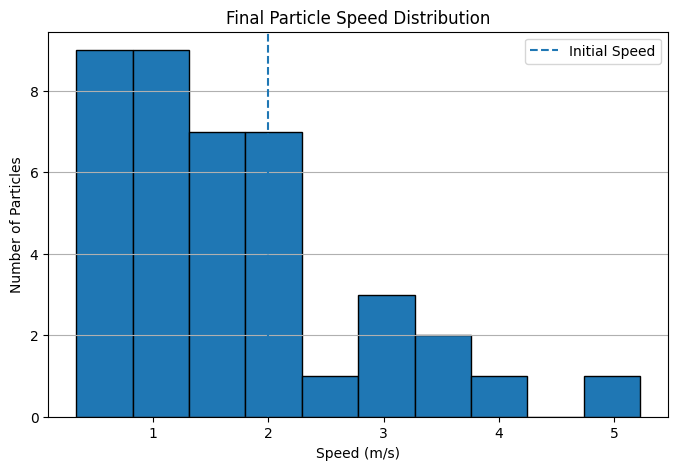

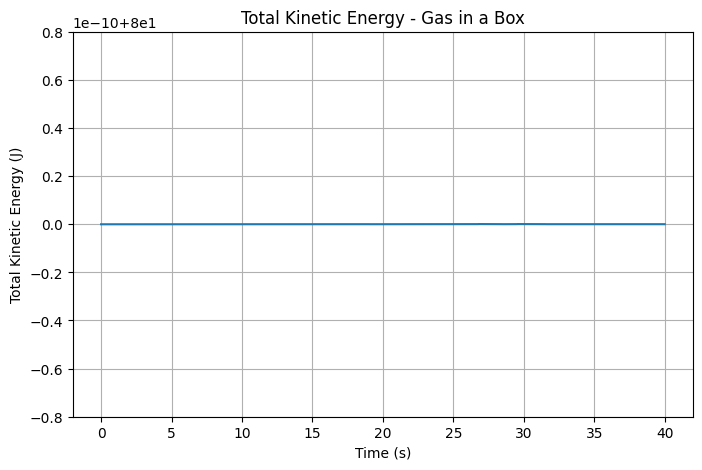

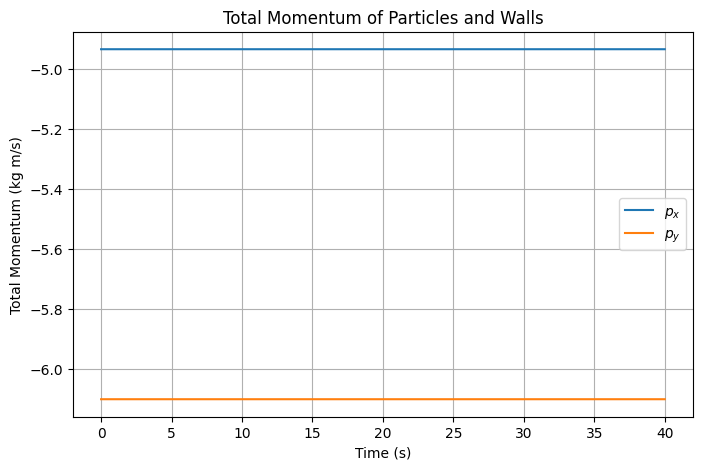

In [28]:
# BONUS - GAS IN A BOX

# B1. SIMULATION PARAMETERS

N = 40

W_gas = 10.0
H_gas = 10.0

mass_gas = 1.0
radius_gas = 0.18
speed_initial = 2.0

dt_gas = 0.005
n_steps_gas = 8000

e_gas = 1.0

rng = np.random.default_rng(311)


# B2. CREATE NON-OVERLAPPING PARTICLES

def create_gas(
    N,
    W,
    H,
    mass,
    radius,
    speed,
    rng
):
    """Create N identical particles with random positions and directions."""
    
    bodies = []
    
    for i in range(N):
        
        # Find a position that does not overlap another particle
        for attempt in range(10000):
            
            position = np.array([
                rng.uniform(radius, W - radius),
                rng.uniform(radius, H - radius)
            ])
            
            valid_position = True
            
            for body in bodies:
                
                distance = np.linalg.norm(
                    position - body["r"]
                )
                
                if distance < (
                    radius + body["radius"]
                ):
                    valid_position = False
                    break
            
            if valid_position:
                break
        
        if not valid_position:
            raise RuntimeError(
                "Could not place all particles without overlap."
            )
        
        # Random direction, same speed for every particle
        theta = rng.uniform(
            0.0,
            2.0 * np.pi
        )
        
        velocity = speed * np.array([
            np.cos(theta),
            np.sin(theta)
        ])
        
        bodies.append({
            "m": mass,
            "r": position,
            "v": velocity,
            "radius": radius
        })
    
    return bodies


# B3. WALL COLLISION WITH MOMENTUM BOOKKEEPING

def bounce_walls_with_impulse(
    body,
    W,
    H
):
    """
    Reflect a particle from the walls and return the
    momentum change of the particle.
    """
    
    R = body["radius"]
    
    velocity_before = body["v"].copy()
    
    x, y = body["r"]
    vx, vy = body["v"]
    
    # Left wall
    if x - R < 0:
        
        x = R
        
        if vx < 0:
            vx = -vx
    
    # Right wall
    elif x + R > W:
        
        x = W - R
        
        if vx > 0:
            vx = -vx
    
    # Bottom wall
    if y - R < 0:
        
        y = R
        
        if vy < 0:
            vy = -vy
    
    # Top wall
    elif y + R > H:
        
        y = H - R
        
        if vy > 0:
            vy = -vy
    
    body["r"] = np.array(
        [x, y],
        dtype=float
    )
    
    body["v"] = np.array(
        [vx, vy],
        dtype=float
    )
    
    # Impulse delivered to the particle by the wall
    impulse = (
        body["m"]
        * (
            body["v"]
            - velocity_before
        )
    )
    
    return impulse


# B4. POSITIONAL CORRECTION

def separate_bodies(
    body1,
    body2
):
    """
    Move overlapping particles apart without changing velocity.
    This helps prevent particles from remaining interpenetrated.
    """
    
    displacement = (
        body2["r"]
        - body1["r"]
    )
    
    distance = np.linalg.norm(
        displacement
    )
    
    minimum_distance = (
        body1["radius"]
        + body2["radius"]
    )
    
    overlap_amount = (
        minimum_distance
        - distance
    )
    
    if overlap_amount <= 0:
        return
    
    if distance == 0:
        
        normal = np.array(
            [1.0, 0.0]
        )
    
    else:
        
        normal = (
            displacement
            / distance
        )
    
    total_mass = (
        body1["m"]
        + body2["m"]
    )
    
    # Move each particle while keeping the COM unchanged
    body1["r"] -= (
        normal
        * overlap_amount
        * body2["m"]
        / total_mass
    )
    
    body2["r"] += (
        normal
        * overlap_amount
        * body1["m"]
        / total_mass
    )


# B5. GAS SIMULATION

def simulate_gas(
    initial_bodies,
    W,
    H,
    dt,
    n_steps,
    e=1.0
):
    """Simulate many particles bouncing elastically in a box."""
    
    bodies = copy_bodies(
        initial_bodies
    )
    
    N = len(bodies)
    
    time = (
        np.arange(
            n_steps + 1
        )
        * dt
    )
    
    kinetic_energy = np.zeros(
        n_steps + 1
    )
    
    ball_momentum = np.zeros(
        (n_steps + 1, 2)
    )
    
    system_momentum = np.zeros(
        (n_steps + 1, 2)
    )
    
    wall_momentum = np.zeros(2)
    
    kinetic_energy[0] = total_ke(
        bodies
    )
    
    ball_momentum[0] = total_momentum(
        bodies
    )
    
    system_momentum[0] = (
        ball_momentum[0]
        + wall_momentum
    )
    
    collision_count = 0
    
    for step in range(
        1,
        n_steps + 1
    ):
        
        # ----------------------------------
        # MOVE PARTICLES
        # ----------------------------------
        
        for body in bodies:
            
            acceleration = np.zeros(2)
            
            # Euler-Cromer
            body["v"] = (
                body["v"]
                + acceleration * dt
            )
            
            body["r"] = (
                body["r"]
                + body["v"] * dt
            )
            
            # Wall collision
            impulse_on_ball = (
                bounce_walls_with_impulse(
                    body,
                    W,
                    H
                )
            )
            
            # Equal and opposite momentum goes to wall
            wall_momentum -= (
                impulse_on_ball
            )
        
        
        # ----------------------------------
        # CHECK ALL UNIQUE PARTICLE PAIRS
        # ----------------------------------
        
        for i in range(N):
            
            for j in range(
                i + 1,
                N
            ):
                
                body1 = bodies[i]
                body2 = bodies[j]
                
                if overlapping(
                    body1["r"],
                    body2["r"],
                    body1["radius"],
                    body2["radius"]
                ):
                    
                    approaching = (
                        np.dot(
                            body2["v"]
                            - body1["v"],
                            body2["r"]
                            - body1["r"]
                        )
                        < 0
                    )
                    
                    if approaching:
                        
                        body1["v"], body2["v"] = collide_2d(
                            body1["m"],
                            body2["m"],
                            body1["r"],
                            body2["r"],
                            body1["v"],
                            body2["v"],
                            e
                        )
                        
                        collision_count += 1
                    
                    # Correct any overlap
                    separate_bodies(
                        body1,
                        body2
                    )
        
        
        # ----------------------------------
        # SAVE CONSERVATION DATA
        # ----------------------------------
        
        kinetic_energy[step] = total_ke(
            bodies
        )
        
        ball_momentum[step] = total_momentum(
            bodies
        )
        
        system_momentum[step] = (
            ball_momentum[step]
            + wall_momentum
        )
    
    
    final_speeds = np.array([
        np.linalg.norm(
            body["v"]
        )
        for body in bodies
    ])
    
    return (
        time,
        kinetic_energy,
        ball_momentum,
        system_momentum,
        final_speeds,
        collision_count
    )


# B6. CREATE GAS

bodies_gas = create_gas(
    N,
    W_gas,
    H_gas,
    mass_gas,
    radius_gas,
    speed_initial,
    rng
)


# Initial speeds for comparison

initial_speeds = np.array([
    np.linalg.norm(
        body["v"]
    )
    for body in bodies_gas
])


# B7. RUN SIMULATION

(
    time_gas,
    ke_gas,
    p_balls_gas,
    p_system_gas,
    final_speeds,
    collisions_gas
) = simulate_gas(
    bodies_gas,
    W_gas,
    H_gas,
    dt_gas,
    n_steps_gas,
    e_gas
)


# B8. NUMERICAL RESULTS

initial_ke_gas = (
    ke_gas[0]
)

final_ke_gas = (
    ke_gas[-1]
)

max_ke_error = np.max(
    np.abs(
        ke_gas
        - initial_ke_gas
    )
)

initial_p_system = (
    p_system_gas[0]
)

momentum_error = (
    p_system_gas
    - initial_p_system
)

max_momentum_error = np.max(
    np.linalg.norm(
        momentum_error,
        axis=1
    )
)

print("GAS IN A BOX RESULTS")

print(
    f"Number of particles: {N}"
)

print(
    f"Number of particle-particle collisions: "
    f"{collisions_gas}"
)

print(
    f"Initial KE = "
    f"{initial_ke_gas:.8f} J"
)

print(
    f"Final KE   = "
    f"{final_ke_gas:.8f} J"
)

print(
    f"Maximum KE deviation = "
    f"{max_ke_error:.3e} J"
)

print(
    f"Initial system momentum = "
    f"({initial_p_system[0]:.8f}, "
    f"{initial_p_system[1]:.8f}) kg m/s"
)

print(
    f"Maximum system momentum deviation = "
    f"{max_momentum_error:.3e} kg m/s"
)


# B9. FINAL SPEED HISTOGRAM

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    final_speeds,
    bins=10,
    edgecolor="black"
)

plt.axvline(
    speed_initial,
    linestyle="--",
    label="Initial Speed"
)

plt.xlabel(
    "Speed (m/s)"
)

plt.ylabel(
    "Number of Particles"
)

plt.title(
    "Final Particle Speed Distribution"
)

plt.grid(
    axis="y"
)

plt.legend()

plt.show()


# B10. KINETIC ENERGY CONSERVATION

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    time_gas,
    ke_gas
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Total Kinetic Energy (J)"
)

plt.title(
    "Total Kinetic Energy - Gas in a Box"
)

plt.grid()

plt.show()


# B11. TOTAL SYSTEM MOMENTUM

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    time_gas,
    p_system_gas[:, 0],
    label=r"$p_x$"
)

plt.plot(
    time_gas,
    p_system_gas[:, 1],
    label=r"$p_y$"
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Total Momentum (kg m/s)"
)

plt.title(
    "Total Momentum of Particles and Walls"
)

plt.grid()

plt.legend()

plt.show()

## Bonus - Interpretation

The 40 particle gas simulation produced 576 particle to particle collisions. Though every particle started with the same speed of 2.0 m/s, the final speed histogram demonstrates a broad distribution of speeds, with several particles moving slower than the initial speed and others moving substantially faster. This behavior is due to the fact that the elastic collisions continually redistribute kinetic energy and momentum among the individual particle collisions. Though the energy of each particle changes, the total kinetic energy of the system remained constant.

The initial and final kinetic energies were both 80.00000000 J, with a maximum deviation of only 8.527e-14 J. This extremely small differential is once again consistent with what we know of float point precision and verifies the elastic particle to particle and wall collisions conserved the system's total kinetic energy.

Additionally, the initial total momentum of the complete particle to wall system was approximately -4.93318139, -6.09998203 kg m/s. The maximum momentum deviation was only 2.325e-14 kg m/s, which once again is the fault of float point precision. If including the momentum that was oppositely transferred to the walls, the system able to conserve its total momentum.

Finally, the development of a varying range of particle speeds from the initial speed demonstrates how repeated microscopic collisions can produce a statistical distribution. This true even though the system begins in a highly ordered state. With only 40 particles, the histogram is still relatively irregular, but it demonstrates the beginnings of a speed distribution for a gas. Being that temperature is related to the average kinetic energy of the particles rather than every individual particle, we are able to measure a system of particles rather than a singular incredibly fast or slow particle.